# Figure notebook for trait 3106

Workflow:
1. Load the raw `3106` raster and the land/water mask.
2. Inpaint `3106` using the land/water mask.
3. Build the final figure from the saved inpainted raster and write it to PDF.
4. Optionally inpaint the remaining TIFFs afterwards.


In [11]:
# If the imports below fail in your Jupyter environment, run this once and restart the kernel:
# %pip install rasterio scipy


In [12]:
from pathlib import Path

import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.patches import ConnectionPatch, Rectangle
from rasterio.enums import Resampling
from rasterio.transform import Affine
from rasterio.windows import Window, from_bounds
from rasterio.warp import reproject, transform_bounds
from scipy import ndimage

plt.rcParams["font.family"] = "monospace"
plt.rcParams["pdf.compression"] = 9
#plt.rcParams["font.monospace"] = ["DejaVu Sans Mono", "Menlo", "Courier New", "monospace"]

PROJECT_ROOT = Path("/Users/lucadominiak/Desktop/MasterStudium/FS26/Planttraits_SemesterProject/99_temp")
SOURCE_DIR = PROJECT_ROOT / "predictions" / "stl_dense_seed0"
INPAINTED_DIR = PROJECT_ROOT / "predictions" / "stl_dense_seed0_inpainted"
INPAINTED_DIR.mkdir(parents=True, exist_ok=True)

TRAIT_ID = "3106"
TRAIT_FILENAME = f"{TRAIT_ID}.tif"
TRAIT_SOURCE_PATH = SOURCE_DIR / TRAIT_FILENAME
TRAIT_INPAINTED_PATH = INPAINTED_DIR / TRAIT_FILENAME
LAND_MASK_PATH = PROJECT_ROOT / "eo_processed" / "worldcover_land_mask_6933.tif"

OUTPUT_FIGURE = PROJECT_ROOT / "code" / "figures" / f"trait_{TRAIT_ID}_global_insets.pdf"
OUTPUT_FIGURE.parent.mkdir(parents=True, exist_ok=True)

FIGSIZE = (18, 10)
MAIN_MAP_PANEL = [0.10, 0.09, 0.80, 0.64]

MAX_FILL_DISTANCE_KM = 250.0
WINDOW_PADDING_DEG = 0.25

COLOR_MIN = 0.0
COLOR_MAX = 10.0

BACKGROUND_COLOR = "#1a1a18"
TRANSPARENT = BACKGROUND_COLOR
TRANSPARENT = "#1a1a18"
LABEL_BOX_FACE = "#1a1a18"
LINE_COLOR = "#FFFFFF"
CONNECTOR_COLOR = "#FFFFFF"
MARKER_COLOR = "#ffffff"
TEXT_COLOR = "#FFFFFF"
TEXT_STROKE_COLOR = "#ffffff"

REGIONS = {
    "Switzerland": {
        "bounds": (5.7, 45.6, 10.8, 47.9),
        "panel": [0.008, 0.735, 0.295, 0.235],
        "anchor": (1.0, 0.35),
    },
    "India": {
        "bounds": (67.5, 6.0, 92.5, 35.5),
        "panel": [0.882, 0.71, 0.115, 0.265],
        "anchor": (0.0, 0.35),
    },
    "Brazil": {
        "bounds": (-72.0, -24.0, -42.0, 5.5),
        "panel": [0.103, 0.045, 0.126, 0.27],
        "anchor": (1.0, 0.72),
    },
    "Madagascar": {
        "bounds": (43.0, -26.5, 51.2, -11.5),
        "panel": [0.862, 0.055, 0.078, 0.265],
        "anchor": (0.0, 0.65),
    },
}

plant_height_cmap = LinearSegmentedColormap.from_list(
    "plant_height_magma_custom",
    [
        "#090611",
        "#1a1233",
        "#30225f",
        "#5a247c",
        "#93308d",
        "#d34278",
        "#f46d5e",
        "#fba66d",
        "#fff2a3",
    ],
    N=256,
)
plant_height_cmap.set_bad(TRANSPARENT)


In [13]:
def scaled_transform(transform, src_width, src_height, out_width, out_height):
    return transform * Affine.scale(src_width / out_width, src_height / out_height)


def plotting_extent(transform, shape):
    """Return extent in Matplotlib order: (left, right, bottom, top)."""
    height, width = shape
    left = transform.c
    top = transform.f
    right = left + transform.a * width
    bottom = top + transform.e * height
    return (min(left, right), max(left, right), min(bottom, top), max(bottom, top))


def reproject_mask(mask_src, dst_shape, dst_transform, dst_crs):
    mask = np.zeros(dst_shape, dtype="uint8")
    reproject(
        source=rasterio.band(mask_src, 1),
        destination=mask,
        src_transform=mask_src.transform,
        src_crs=mask_src.crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        dst_nodata=0,
        resampling=Resampling.nearest,
    )
    return mask.astype(bool)


def fill_land_gaps(data, land_mask, pixel_size_m, max_fill_distance_km=None):
    observed_mask = np.isfinite(data) & land_mask
    targets = land_mask & ~observed_mask

    filled = data.copy()
    imputed = np.zeros_like(observed_mask, dtype=bool)

    if not targets.any() or not observed_mask.any():
        filled[~land_mask] = np.nan
        return filled, imputed, observed_mask

    distances, nearest_indices = ndimage.distance_transform_edt(
        ~observed_mask,
        return_distances=True,
        return_indices=True,
    )

    eligible = targets
    if max_fill_distance_km is not None:
        eligible = eligible & ((distances * pixel_size_m) <= max_fill_distance_km * 1000.0)

    filled[eligible] = data[tuple(nearest_indices[:, eligible])]
    filled[~land_mask] = np.nan
    imputed[eligible] = True
    return filled, imputed, observed_mask


def read_resampled(src, out_shape, resampling, masked=False):
    arr = src.read(1, out_shape=out_shape, masked=masked, resampling=resampling)
    if masked:
        arr = arr.filled(np.nan)
    return np.asarray(arr, dtype="float32")


def write_inpainted_prediction(src_path, dst_path, land_mask_src):
    with rasterio.open(src_path) as src:
        data = src.read(1, masked=True).filled(np.nan).astype("float32")
        land_mask = reproject_mask(land_mask_src, data.shape, src.transform, src.crs)
        pixel_size_m = 0.5 * (abs(src.transform.a) + abs(src.transform.e))
        filled, imputed, observed_mask = fill_land_gaps(
            data,
            land_mask,
            pixel_size_m=pixel_size_m,
            max_fill_distance_km=MAX_FILL_DISTANCE_KM,
        )

        profile = src.profile.copy()
        profile.update(dtype="float32", nodata=np.nan, compress="lzw")
        dst_path.parent.mkdir(parents=True, exist_ok=True)
        with rasterio.open(dst_path, "w", **profile) as dst:
            dst.write(filled, 1)

        return {
            "name": src_path.name,
            "output_path": dst_path,
            "imputed_pixels": int(imputed.sum()),
            "observed_land_pixels": int(observed_mask.sum()),
            "land_pixels": int(land_mask.sum()),
        }


def batch_inpaint_predictions(source_dir, output_dir, land_mask_path, skip_names=None):
    skip_names = set(skip_names or [])
    tif_paths = sorted(path for path in source_dir.glob("*.tif") if path.name not in skip_names)
    if not tif_paths:
        print("No TIFF files selected for batch inpainting.")
        return []

    results = []
    with rasterio.open(land_mask_path) as land_mask_src:
        for src_path in tif_paths:
            dst_path = output_dir / src_path.name
            result = write_inpainted_prediction(src_path, dst_path, land_mask_src)
            results.append(result)
            print(
                f"Inpainted {src_path.name} -> {dst_path.name} "
                f"({result['imputed_pixels']:,} pixels)"
            )

    return results


def finalize_plot_data(data, observed_mask, land_mask):
    plot_data = np.asarray(data, dtype="float32").copy()
    plot_data[~land_mask] = np.nan
    imputed = land_mask & ~observed_mask & np.isfinite(plot_data)
    return plot_data, imputed


def native_export_dpi(src_width, src_height, figsize, axes_panel):
    fig_width_in, fig_height_in = figsize
    _, _, panel_width, panel_height = axes_panel
    dpi_width = src_width / (fig_width_in * panel_width)
    dpi_height = src_height / (fig_height_in * panel_height)
    return int(np.ceil(max(dpi_width, dpi_height)))


def make_global_product(plot_src, raw_src, land_mask_src):
    plot_data = plot_src.read(1, masked=True).filled(np.nan).astype("float32")
    raw_data = raw_src.read(1, masked=True).filled(np.nan).astype("float32")
    observed_mask = np.isfinite(raw_data)

    transform = plot_src.transform
    land_mask = reproject_mask(land_mask_src, plot_data.shape, transform, plot_src.crs)
    plot_data, imputed = finalize_plot_data(plot_data, observed_mask, land_mask)

    return {
        "data": plot_data,
        "extent": plotting_extent(transform, plot_data.shape),
        "transform": transform,
        "imputed_mask": imputed,
        "imputed_pixels": int(imputed.sum()),
    }


def read_region_product(plot_src, raw_src, land_mask_src, lonlat_bounds):
    lon_min, lat_min, lon_max, lat_max = lonlat_bounds
    padded_bounds = (
        lon_min - WINDOW_PADDING_DEG,
        lat_min - WINDOW_PADDING_DEG,
        lon_max + WINDOW_PADDING_DEG,
        lat_max + WINDOW_PADDING_DEG,
    )

    padded_proj_bounds = transform_bounds("EPSG:4326", plot_src.crs, *padded_bounds, densify_pts=41)
    map_bounds = transform_bounds("EPSG:4326", plot_src.crs, *lonlat_bounds, densify_pts=41)

    full_window = Window(col_off=0, row_off=0, width=plot_src.width, height=plot_src.height)
    window = from_bounds(*padded_proj_bounds, transform=plot_src.transform)
    window = window.round_offsets().round_lengths().intersection(full_window)

    plot_data = plot_src.read(1, window=window, masked=True).filled(np.nan).astype("float32")
    raw_data = raw_src.read(1, window=window, masked=True).filled(np.nan).astype("float32")
    observed_mask = np.isfinite(raw_data)
    transform = plot_src.window_transform(window)
    land_mask = reproject_mask(land_mask_src, plot_data.shape, transform, plot_src.crs)
    plot_data, imputed = finalize_plot_data(plot_data, observed_mask, land_mask)

    return {
        "data": plot_data,
        "extent": plotting_extent(transform, plot_data.shape),
        "map_bounds": map_bounds,
        "imputed_pixels": int(imputed.sum()),
    }


def add_scalebar(ax, extent, color=LINE_COLOR):
    left, right, bottom, top = extent
    width_km = (right - left) / 1000.0
    target = width_km * 0.22
    choices = np.array([25, 50, 100, 200, 300, 500, 1000, 1500, 2000])
    length_km = float(choices[np.argmin(np.abs(choices - target))])

    x0 = left + 0.08 * (right - left)
    y0 = bottom + 0.08 * (top - bottom)
    x1 = x0 + length_km * 1000.0

    ax.plot([x0, x1], [y0, y0], color=color, linewidth=3, solid_capstyle="butt")
    ax.text(
        x0,
        y0 + 0.04 * (top - bottom),
        f"{int(length_km)} km",
        color=color,
        fontsize=8,
        fontfamily="sans-serif",
        fontweight="normal",
        ha="left",
        va="bottom",
        bbox=dict(facecolor=BACKGROUND_COLOR, edgecolor="none", alpha=0.88, pad=0.8),
        zorder=10,
    )


def style_inset_axis(ax, name):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor(BACKGROUND_COLOR)

    for spine in ax.spines.values():
        spine.set_color(LINE_COLOR)
        spine.set_linewidth(0.9)

    ax.text(
        0.05,
        0.94,
        name,
        transform=ax.transAxes,
        ha="left",
        va="top",
        color=TEXT_COLOR,
        fontsize=11,
        fontweight="normal",
        fontfamily="sans-serif",
        path_effects=[pe.withStroke(linewidth=1.2, foreground=BACKGROUND_COLOR)],
        bbox=dict(facecolor=BACKGROUND_COLOR, edgecolor="none", alpha=0.90, pad=2.0),
        zorder=10,
    )


In [14]:
with rasterio.open(TRAIT_SOURCE_PATH) as trait_src, rasterio.open(LAND_MASK_PATH) as land_mask_src:
    print(f"Trait source: {TRAIT_SOURCE_PATH}")
    print(f"  shape={trait_src.height}x{trait_src.width}, crs={trait_src.crs}, dtype={trait_src.dtypes[0]}")
    print(f"Land/water mask: {LAND_MASK_PATH}")
    print(f"  shape={land_mask_src.height}x{land_mask_src.width}, crs={land_mask_src.crs}, dtype={land_mask_src.dtypes[0]}")


Trait source: /Users/lucadominiak/Desktop/MasterStudium/FS26/Planttraits_SemesterProject/99_temp/predictions/stl_dense_seed0/3106.tif
  shape=14682x34734, crs=EPSG:6933, dtype=float32
Land/water mask: /Users/lucadominiak/Desktop/MasterStudium/FS26/Planttraits_SemesterProject/99_temp/eo_processed/worldcover_land_mask_6933.tif
  shape=14682x34734, crs=EPSG:6933, dtype=uint8


In [15]:
with rasterio.open(LAND_MASK_PATH) as land_mask_src:
    trait_inpainting_result = write_inpainted_prediction(
        TRAIT_SOURCE_PATH,
        TRAIT_INPAINTED_PATH,
        land_mask_src,
    )

print(f"Saved inpainted {TRAIT_ID} raster to: {TRAIT_INPAINTED_PATH}")
print(f"{TRAIT_ID} full-resolution imputed pixels: {trait_inpainting_result['imputed_pixels']:,}")
print(f"{TRAIT_ID} observed land pixels: {trait_inpainting_result['observed_land_pixels']:,}")


Saved inpainted 3106 raster to: /Users/lucadominiak/Desktop/MasterStudium/FS26/Planttraits_SemesterProject/99_temp/predictions/stl_dense_seed0_inpainted/3106.tif
3106 full-resolution imputed pixels: 5,631,888
3106 observed land pixels: 128,190,401


Plot source raster: /Users/lucadominiak/Desktop/MasterStudium/FS26/Planttraits_SemesterProject/99_temp/predictions/stl_dense_seed0_inpainted/3106.tif
Global imputed pixels (display grid): 5,631,888
Export DPI for native main-map resolution: 2413
Color scale: 0.0 to 10.0 m
Switzerland  -> imputed 7,332 pixels
India        -> imputed 162,530 pixels
Brazil       -> imputed 133,894 pixels
Madagascar   -> imputed 10,017 pixels


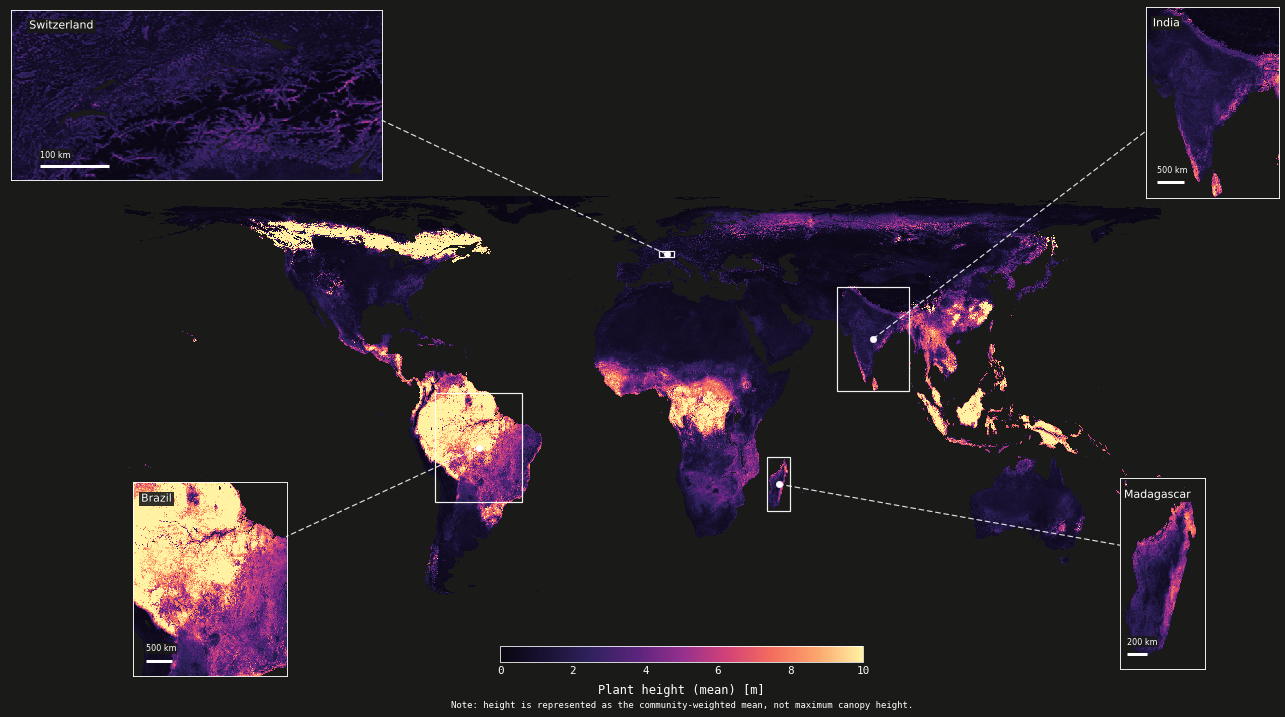

Saved figure to: /Users/lucadominiak/Desktop/MasterStudium/FS26/Planttraits_SemesterProject/99_temp/code/figures/trait_3106_global_insets.pdf


In [16]:
with rasterio.open(TRAIT_SOURCE_PATH) as raw_trait_src, rasterio.open(TRAIT_INPAINTED_PATH) as plot_trait_src, rasterio.open(LAND_MASK_PATH) as land_mask_src:
    export_dpi = native_export_dpi(plot_trait_src.width, plot_trait_src.height, FIGSIZE, MAIN_MAP_PANEL)
    global_product = make_global_product(plot_trait_src, raw_trait_src, land_mask_src)
    region_products = {
        name: read_region_product(plot_trait_src, raw_trait_src, land_mask_src, cfg["bounds"])
        for name, cfg in REGIONS.items()
    }

finite_values = global_product["data"][np.isfinite(global_product["data"])]
if finite_values.size == 0:
    raise ValueError("No finite pixels available for plotting.")

vmin, vmax = COLOR_MIN, COLOR_MAX

print(f"Plot source raster: {TRAIT_INPAINTED_PATH}")
print(f"Global imputed pixels (display grid): {global_product['imputed_pixels']:,}")
print(f"Export DPI for native main-map resolution: {export_dpi}")
print(f"Color scale: {vmin:.1f} to {vmax:.1f} m")
for name, product in region_products.items():
    print(f"{name:12s} -> imputed {product['imputed_pixels']:,} pixels")

fig = plt.figure(figsize=FIGSIZE, facecolor=BACKGROUND_COLOR)
fig.patch.set_alpha(1.0)

ax_map = fig.add_axes(MAIN_MAP_PANEL, facecolor=BACKGROUND_COLOR)
ax_map.imshow(
    global_product["data"],
    extent=global_product["extent"],
    origin="upper",
    cmap=plant_height_cmap,
    vmin=vmin,
    vmax=vmax,
    interpolation="none",
)
ax_map.set_xticks([])
ax_map.set_yticks([])
ax_map.set_facecolor(TRANSPARENT)
for spine in ax_map.spines.values():
    spine.set_color(TRANSPARENT)
    spine.set_linewidth(0.8)

for name, cfg in REGIONS.items():
    product = region_products[name]
    left, bottom, right, top = product["map_bounds"]

    rect = Rectangle(
        (left, bottom),
        right - left,
        top - bottom,
        facecolor="none",
        edgecolor=LINE_COLOR,
        linewidth=1.2,
        alpha=0.95,
        zorder=5,
    )
    ax_map.add_patch(rect)

    x_center = 0.5 * (left + right)
    y_center = 0.5 * (bottom + top)
    ax_map.scatter(
        x_center,
        y_center,
        s=42,
        color=MARKER_COLOR,
        linewidths=0.5,
        zorder=6,
    )

    ax_inset = fig.add_axes(cfg["panel"], facecolor=TRANSPARENT)
    ax_inset.imshow(
        product["data"],
        extent=product["extent"],
        origin="upper",
        cmap=plant_height_cmap,
        vmin=vmin,
        vmax=vmax,
        interpolation="none",
    )
    style_inset_axis(ax_inset, name)
    add_scalebar(ax_inset, product["extent"])

    connector = ConnectionPatch(
        xyA=(x_center, y_center),
        coordsA=ax_map.transData,
        xyB=cfg["anchor"],
        coordsB=ax_inset.transAxes,
        linestyle=(0, (4, 3)),
        linewidth=1.2,
        color=CONNECTOR_COLOR,
        alpha=0.85,
        zorder=4,
    )
    fig.add_artist(connector)

cax = fig.add_axes([0.39, 0.065, 0.28, 0.022], facecolor=TRANSPARENT)
sm = plt.cm.ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=plant_height_cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
cbar.ax.set_facecolor(TRANSPARENT)
cbar.outline.set_edgecolor(LINE_COLOR)
cbar.outline.set_linewidth(0.8)
cbar.ax.tick_params(colors=TEXT_COLOR, labelsize=11, length=0)
cbar.set_ticks(np.arange(0, 11, 2))
cbar.set_label("Plant height (mean) [m]", color=TEXT_COLOR, fontsize=12, labelpad=8)
cbar.ax.text(
    0.5,
    -2.45,
    "Note: height is represented as the community-weighted mean, not maximum canopy height.",
    transform=cbar.ax.transAxes,
    ha="center",
    va="top",
    color=TEXT_COLOR,
    fontsize=9,
    #path_effects=[pe.withStroke(linewidth=2, foreground=TEXT_STROKE_COLOR)],
)

fig.savefig(
    OUTPUT_FIGURE,
    dpi=export_dpi,
    transparent=False,
    facecolor=BACKGROUND_COLOR,
    edgecolor=BACKGROUND_COLOR,
    bbox_inches="tight",
    pad_inches=0.02,
)
plt.show()

print(f"Saved figure to: {OUTPUT_FIGURE}")


In [17]:
# Optional: inpaint the remaining TIFFs after plotting.
other_inpainting_results = batch_inpaint_predictions(
    SOURCE_DIR,
    INPAINTED_DIR,
    LAND_MASK_PATH,
    skip_names={TRAIT_FILENAME},
)
print(f"Saved {len(other_inpainting_results)} additional inpainted rasters to {INPAINTED_DIR}")


Inpainted 1080.tif -> 1080.tif (5,631,888 pixels)
Inpainted 13.tif -> 13.tif (5,631,888 pixels)
Inpainted 138.tif -> 138.tif (5,631,888 pixels)
Inpainted 14.tif -> 14.tif (5,631,888 pixels)
Inpainted 144.tif -> 144.tif (5,631,888 pixels)
Inpainted 145.tif -> 145.tif (5,631,888 pixels)
Inpainted 146.tif -> 146.tif (5,631,888 pixels)
Inpainted 15.tif -> 15.tif (5,631,888 pixels)
Inpainted 163.tif -> 163.tif (5,631,888 pixels)
Inpainted 169.tif -> 169.tif (5,631,888 pixels)
Inpainted 21.tif -> 21.tif (5,631,888 pixels)
Inpainted 223.tif -> 223.tif (0 pixels)
Inpainted 224.tif -> 224.tif (0 pixels)
Inpainted 237.tif -> 237.tif (5,631,888 pixels)
Inpainted 26.tif -> 26.tif (5,631,888 pixels)
Inpainted 27.tif -> 27.tif (5,631,888 pixels)
Inpainted 281.tif -> 281.tif (5,631,888 pixels)
Inpainted 282.tif -> 282.tif (5,631,888 pixels)
Inpainted 289.tif -> 289.tif (5,631,888 pixels)
Inpainted 297.tif -> 297.tif (5,631,888 pixels)
Inpainted 3107.tif -> 3107.tif (0 pixels)
Inpainted 3112.tif -> 31